In [1]:
import pandas as pd

df = pd.read_csv('data.csv')
print(df.shape)
print(df.head())
print(df.info())

(1242, 11)
  tech_company      benefits workplace_resources mh_employer_discussion  \
0          Yes            No        I don't know                     No   
1          Yes           Yes                  No                     No   
2          Yes  I don't know                  No                    Yes   
3          Yes           Yes        I don't know                    Yes   
4          Yes           Yes                  No                     No   

  mh_coworker_discussion medical_coverage mental_health  mh_share   age  \
0                    Yes              Yes      Possibly         5  27.0   
1                    Yes              Yes      Possibly         4  31.0   
2                    Yes               No           Yes         5  36.0   
3                    Yes              Yes           Yes        10  22.0   
4                    Yes              Yes           Yes         8  36.0   

   gender                   country  
0  Female            United Kingdom  
1    Male  

In [2]:
for col in df.columns:
    print(f"\n{col}:")
    print(df[col].value_counts())


tech_company:
tech_company
Yes    899
No     343
Name: count, dtype: int64

benefits:
benefits
Yes             781
I don't know    308
No              153
Name: count, dtype: int64

workplace_resources:
workplace_resources
No              465
Yes             431
I don't know    346
Name: count, dtype: int64

mh_employer_discussion:
mh_employer_discussion
No     832
Yes    410
Name: count, dtype: int64

mh_coworker_discussion:
mh_coworker_discussion
No     679
Yes    563
Name: count, dtype: int64

medical_coverage:
medical_coverage
Yes    1147
No       95
Name: count, dtype: int64

mental_health:
mental_health
Yes           553
No            345
Possibly      257
Don't Know     87
Name: count, dtype: int64

mh_share:
mh_share
10    201
8     199
7     187
5     156
9     135
6     115
2      69
3      58
4      57
0      38
1      27
Name: count, dtype: int64

age:
age
30.000000    73
37.000000    70
32.000000    62
35.000000    60
28.000000    60
31.000000    55
27.000000    54
34.000

In [3]:
for col in df.columns:
    print(f"\n{col}:")
    print(df[col].unique())


tech_company:
['Yes' 'No']

benefits:
['No' 'Yes' "I don't know"]

workplace_resources:
["I don't know" 'No' 'Yes']

mh_employer_discussion:
['No' 'Yes']

mh_coworker_discussion:
['Yes' 'No']

medical_coverage:
['Yes' 'No']

mental_health:
['Possibly' 'Yes' 'No' "Don't Know"]

mh_share:
[ 5  4 10  8  3  2  9  7  6  1  0]

age:
[27.         31.         36.         22.         38.         40.
 35.         28.         21.         37.         25.         66.
 32.         30.         39.         33.         42.         47.
 64.         44.         26.         45.         23.         46.
 50.         34.         24.         52.         43.         54.
 48.         29.         49.         20.         62.         51.
 60.         41.         59.         57.         56.         55.
 53.         19.         61.         65.         35.00241546 63.
 58.        ]

gender:
['Female' 'Male' 'Other']

country:
['United Kingdom' 'United States of America' 'Germany' 'Canada' 'Portugal'
 'Spain' 'Austra

In [4]:
print(df['gender'].unique())

['Female' 'Male' 'Other']


In [5]:
# Check for missing values
print(df.isnull().sum())

# Check age range (sometimes has outliers)
print(df['age'].describe())

tech_company              0
benefits                  0
workplace_resources       0
mh_employer_discussion    0
mh_coworker_discussion    0
medical_coverage          0
mental_health             0
mh_share                  0
age                       0
gender                    0
country                   0
dtype: int64
count    1242.000000
mean       35.030598
std         8.186624
min        19.000000
25%        29.000000
50%        34.000000
75%        40.000000
max        66.000000
Name: age, dtype: float64


In [6]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()

# Encode all object columns
le = LabelEncoder()
for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

print(df_encoded.head())
print(df_encoded.dtypes)

   tech_company  benefits  workplace_resources  mh_employer_discussion  \
0             1         1                    0                       0   
1             1         2                    1                       0   
2             1         0                    1                       1   
3             1         2                    0                       1   
4             1         2                    1                       0   

   mh_coworker_discussion  medical_coverage  mental_health  mh_share   age  \
0                       1                 1              2         5  27.0   
1                       1                 1              2         4  31.0   
2                       1                 0              3         5  36.0   
3                       1                 1              3        10  22.0   
4                       1                 1              3         8  36.0   

   gender  country  
0       0       28  
1       1       28  
2       1       29  
3 

In [7]:
df_encoded.to_csv('data_cleaned.csv', index=False)
print("Saved successfully")

Saved successfully


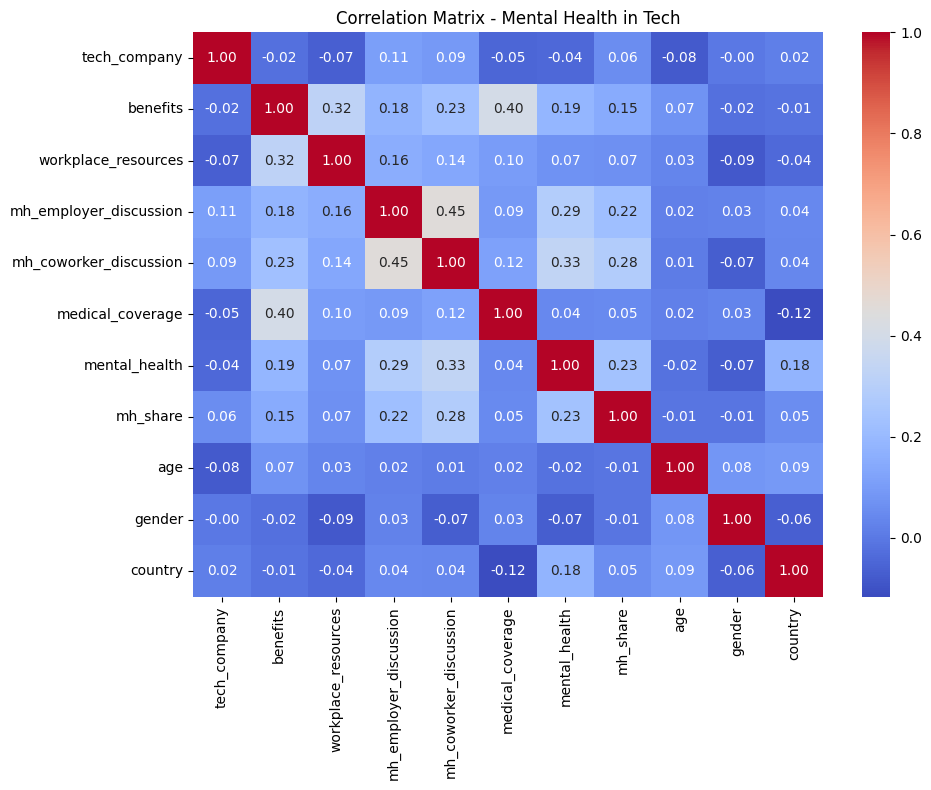

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df_encoded.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix - Mental Health in Tech')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()

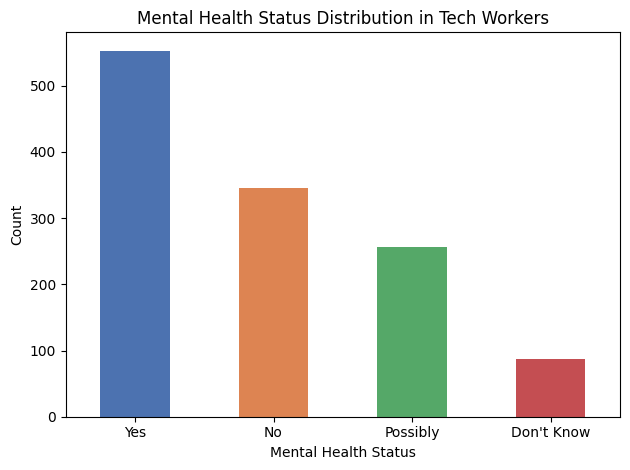

In [9]:
import matplotlib.pyplot as plt

df['mental_health'].value_counts().plot(kind='bar', color=['#4C72B0','#DD8452','#55A868','#C44E52'])
plt.title('Mental Health Status Distribution in Tech Workers')
plt.xlabel('Mental Health Status')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('mental_health_distribution.png')
plt.show()

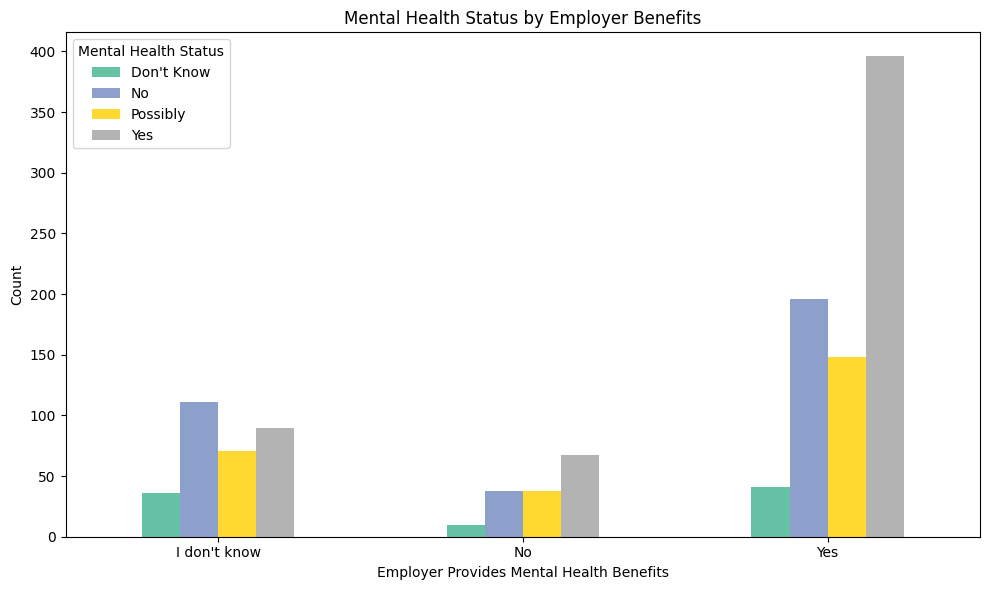

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

ct = pd.crosstab(df['benefits'], df['mental_health'])
ct.plot(kind='bar', figsize=(10,6), colormap='Set2')
plt.title('Mental Health Status by Employer Benefits')
plt.xlabel('Employer Provides Mental Health Benefits')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Mental Health Status')
plt.tight_layout()
plt.savefig('benefits_vs_mental_health.png')
plt.show()

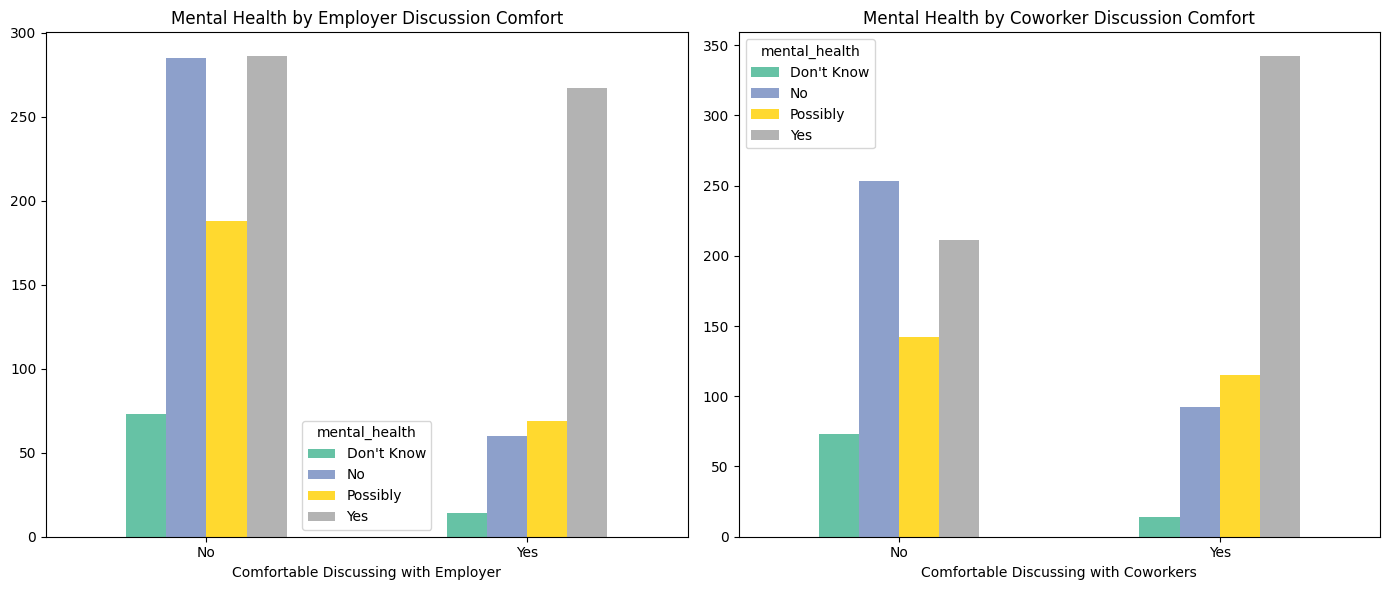

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

pd.crosstab(df['mh_employer_discussion'], df['mental_health']).plot(
    kind='bar', ax=axes[0], colormap='Set2')
axes[0].set_title('Mental Health by Employer Discussion Comfort')
axes[0].set_xlabel('Comfortable Discussing with Employer')
axes[0].set_xticklabels(['No', 'Yes'], rotation=0)

pd.crosstab(df['mh_coworker_discussion'], df['mental_health']).plot(
    kind='bar', ax=axes[1], colormap='Set2')
axes[1].set_title('Mental Health by Coworker Discussion Comfort')
axes[1].set_xlabel('Comfortable Discussing with Coworkers')
axes[1].set_xticklabels(['No', 'Yes'], rotation=0)

plt.tight_layout()
plt.savefig('discussion_vs_mental_health.png')
plt.show()

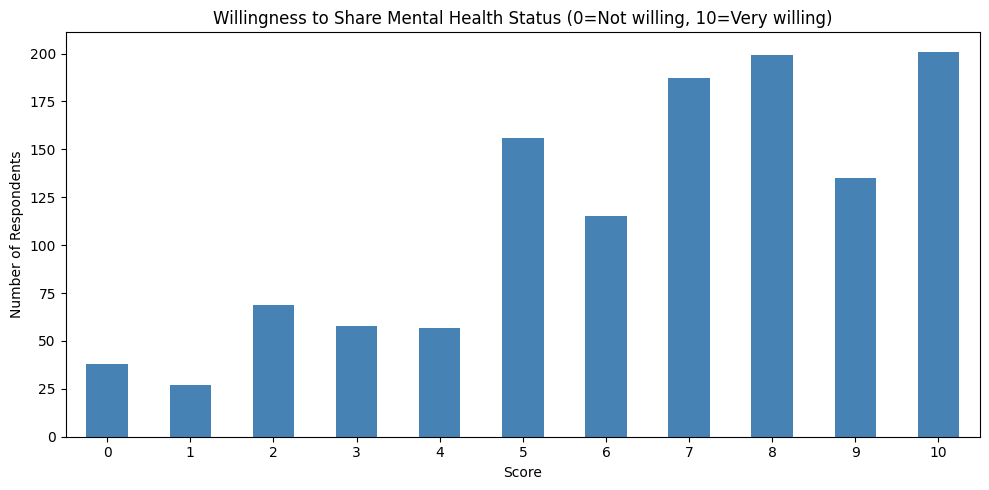

In [12]:
plt.figure(figsize=(10, 5))
df['mh_share'].value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.title('Willingness to Share Mental Health Status (0=Not willing, 10=Very willing)')
plt.xlabel('Score')
plt.ylabel('Number of Respondents')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('mh_share_distribution.png')
plt.show()

In [14]:
import mysql.connector
import pandas as pd

df = pd.read_csv('data.csv')

conn = mysql.connector.connect(
    host='127.0.0.1',
    user='root',
    password='Mindfreak9!@',
    database='mental_health_tech'
)

cursor = conn.cursor()

for _, row in df.iterrows():
    cursor.execute("""
        INSERT INTO survey VALUES (%s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s)
    """, tuple(row))

conn.commit()
cursor.close()
conn.close()
print("Data imported successfully!")

Data imported successfully!
